# **Routing**
Routing is something that decides to which direction or tool we need to goto

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv ,find_dotenv
import os 
load_dotenv(find_dotenv(),override=True)

if os.environ["GOOGLE_API_KEY"]:
    print("API Key found Success")
else:
    raise ValueError("Please Provide an API Key ")

API Key found Success


In [2]:
llm=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

# **Pydantic LLM Schema**

In [3]:
from pydantic import BaseModel , Field
from typing import Literal 

class llm_schema(BaseModel):
      category:Literal['insta','twitter','linkedin']=Field(description="Category of post to generate")
      topic:str=Field(description="Topic of the post Generated ")

In [4]:
llm_with_schema=llm.with_structured_output(llm_schema)

llm_with_schema.invoke(" I want to Generate a LinkedIn post about AI")

llm_schema(category='linkedin', topic='AI')

# **State Schema**

In [5]:
from typing import TypedDict,List

class graph_schema(TypedDict):
    input:str
    topic:str
    post:str
    category:str

# **Node Fucntions & Deciders**

In [6]:
def decider_node(state:graph_schema)-> graph_schema:
    user_input=state['input']
    response=llm_with_schema.invoke(user_input)
    category=response.category
    topic=response.topic
    state['category']=category
    state['topic']=topic
    return state

In [7]:
def create_post_insta(state:graph_schema)-> graph_schema:
    topic =state['topic']
    post=llm-llm_with_schema.invoke(f'Write an instagram post about {topic} Keep the tone engaging and casual').content
    state['post']=post
    return {'post':post}

In [8]:
def create_post_linkedin(state:graph_schema)-> graph_schema:
    topic=state['topic']
    post=llm_with_schema.invoke(f'Create a linkedin post about {topic} . Keep Tone knowledgeable and innovative').content
    state['post']=post
    return {'post':post}

In [9]:
def create_post_twitter(state:graph_schema)->graph_schema:
    topic=state['topic']
    post=llm_with_schema.invoke(f'Create a Twitter post about {topic} . Keep tone Quick').content
    state['post']=post

    return {'post':post}

In [10]:
def condition(state:graph_schema)-> str:
    category=state['category']

    if category=="linkedin":
        return "create_post_linkedin"
    
    elif category =="create_post_twitter":
        return "create_post_twitter"
    
    elif category =="create_post_insta":
        return "create_post_insta"
    
    else:
        raise ValueError("Invalid Category ")

# **Graph Creation**

In [18]:
from langgraph.graph import StateGraph, START,END

graph=StateGraph(state_schema=graph_schema)

graph.add_node("decider",decider_node)
graph.add_node("create_post_insta",create_post_insta)
graph.add_node("create_post_linkedin",create_post_linkedin)
graph.add_node("create_post_twitter",create_post_twitter)


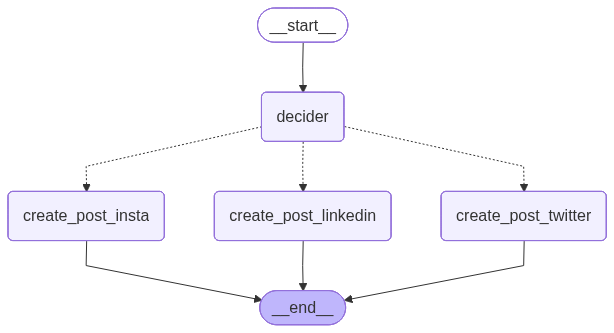

In [19]:
graph.add_edge(START,"decider")
graph.add_conditional_edges("decider",condition,{
    "create_post_insta":"create_post_insta",
    "create_post_linkedin":"create_post_linkedin",
    "create_post_twitter":"create_post_twitter",
})
graph.add_edge("create_post_insta",END)
graph.add_edge("create_post_twitter",END)
graph.add_edge("create_post_linkedin",END)

route_graph=graph.compile()

from IPython.display import Image
Image(route_graph.get_graph().draw_mermaid_png())

